In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def _3d_lidar_points(PATH):
    raw = np.fromfile(PATH, dtype=np.float32)

    # reshape to (x,y,z) and internsity
    lidar_points = raw.reshape(-1,4)

    xyz = lidar_points[:, :3]
    intensity = lidar_points[:, -1]

    return xyz, intensity

xyz, intensity = _3d_lidar_points(PATH = "../data/KITTI/training/velodyne/000000.bin")
xyz

array([[ 1.8324e+01,  4.9000e-02,  8.2900e-01],
       [ 1.8344e+01,  1.0600e-01,  8.2900e-01],
       [ 5.1299e+01,  5.0500e-01,  1.9440e+00],
       ...,
       [ 3.7180e+00, -1.4060e+00, -1.7370e+00],
       [ 3.7140e+00, -1.3910e+00, -1.7330e+00],
       [ 3.9670e+00, -1.4740e+00, -1.8570e+00]],
      shape=(115384, 3), dtype=float32)

In [3]:
def transformation_matrices(PATH):
    with open(PATH) as f:
        lines = f.readlines()

    line = []
    for i in range(0, len(lines)-1):
        line.append(lines[i])

    p0 = line[0].strip().split()[1:]
    p1 = line[1].strip().split()[1:]
    p2 = line[2].strip().split()[1:]
    p3 = line[3].strip().split()[1:]
    r0_rect = line[4].strip().split()[1:]
    tr_velo_to_cam = line[5].strip().split()[1:]
    tr_imu_to_velo = line[6].strip().split()[1:]

    # velo to cam- first tranformation
    tr_velo_to_cam = np.array(tr_velo_to_cam, dtype=np.float32).reshape(3, 4)

    # cam to rectified cam- second transformation
    r0_rect = np.array(r0_rect, dtype=np.float32).reshape(3, 3)

    # to 2d image- prjection
    p2 = np.array(p2, dtype=np.float32).reshape(3, 4)

    return tr_velo_to_cam, r0_rect, p2

tr_velo_to_cam, r0_rect, p2 = transformation_matrices(PATH = "../data/KITTI/training/calib/000000.txt")
print("P2:\n", p2)
print("\nR0_rect:\n", r0_rect)
print("\nT_velo_cam:\n", tr_velo_to_cam)

P2:
 [[ 7.070493e+02  0.000000e+00  6.040814e+02  4.575831e+01]
 [ 0.000000e+00  7.070493e+02  1.805066e+02 -3.454157e-01]
 [ 0.000000e+00  0.000000e+00  1.000000e+00  4.981016e-03]]

R0_rect:
 [[ 0.9999128   0.01009263 -0.00851193]
 [-0.01012729  0.9999406  -0.00403767]
 [ 0.00847067  0.00412352  0.9999556 ]]

T_velo_cam:
 [[ 0.00692796 -0.9999722  -0.00275783 -0.02457729]
 [-0.00116298  0.00274984 -0.9999955  -0.06127237]
 [ 0.9999753   0.00693114 -0.0011439  -0.3321029 ]]


In [4]:
def transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect):

    # Add homogeneous coordinate
    xyz_homogeneous = np.hstack([xyz, np.ones((xyz.shape[0], 1))])

    # LiDAR to camera
    camera_xyz = (tr_velo_to_cam @ xyz_homogeneous.T).T

    # Camera to rectified camera
    rectified_xyz = (r0_rect @ camera_xyz.T).T

    return rectified_xyz

rectified_xyz = transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect)

In [5]:
def projection(rectified_xyz, p2):

    # Add homogeneous coordinate
    rectified_xyz_homogeneous = np.hstack([rectified_xyz, np.ones((rectified_xyz.shape[0], 1))])

    # Project 3D points into image coordinates
    image_coordinates = (p2 @ rectified_xyz_homogeneous.T).T

    # Perspective projection
    u = image_coordinates[:, 0] / image_coordinates[:, 2]
    v = image_coordinates[:, 1] / image_coordinates[:, 2]

    return u, v

In [6]:
def read_labels(PATH):
    objects = []

    with open(PATH) as f:
        for line in f:
            label = line.strip().split()

            object_type = label[0]

            bbox = np.array([
                float(label[4]),
                float(label[5]),
                float(label[6]),
                float(label[7])
            ])

            dimensions = np.array([
                float(label[8]),
                float(label[9]),
                float(label[10])
            ])

            location = np.array([
                float(label[11]),
                float(label[12]),
                float(label[13])
            ])

            rotation_y = float(label[14])

            objects.append({
                "type": object_type,
                "bbox": bbox,
                "dimensions": dimensions,
                "location": location,
                "rotation_y": rotation_y
            })

    return objects

All Functions combined

In [7]:
def _3d_lidar_points(PATH):
    raw = np.fromfile(PATH, dtype=np.float32)

    # reshape to (x,y,z) and internsity
    lidar_points = raw.reshape(-1,4)

    xyz = lidar_points[:, :3]
    intensity = lidar_points[:, -1]

    return xyz, intensity

xyz, intensity = _3d_lidar_points(PATH = "../data/KITTI/training/velodyne/000000.bin")

def transformation_matrices(PATH):
    with open(PATH) as f:
        lines = f.readlines()

    line = []
    for i in range(0, len(lines)-1):
        line.append(lines[i])

    p0 = line[0].strip().split()[1:]
    p1 = line[1].strip().split()[1:]
    p2 = line[2].strip().split()[1:]
    p3 = line[3].strip().split()[1:]
    r0_rect = line[4].strip().split()[1:]
    tr_velo_to_cam = line[5].strip().split()[1:]
    tr_imu_to_velo = line[6].strip().split()[1:]

    # velo to cam- first tranformation
    tr_velo_to_cam = np.array(tr_velo_to_cam, dtype=np.float32).reshape(3, 4)

    # cam to rectified cam- second transformation
    r0_rect = np.array(r0_rect, dtype=np.float32).reshape(3, 3)

    # to 2d image- prjection
    p2 = np.array(p2, dtype=np.float32).reshape(3, 4)

    return tr_velo_to_cam, r0_rect, p2

tr_velo_to_cam, r0_rect, p2 = transformation_matrices(PATH = "../data/KITTI/training/calib/000000.txt")


def transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect):

    # Add homogeneous coordinate
    xyz_homogeneous = np.hstack([xyz, np.ones((xyz.shape[0], 1))])

    # LiDAR to camera
    camera_xyz = (tr_velo_to_cam @ xyz_homogeneous.T).T

    # Camera to rectified camera
    rectified_xyz = (r0_rect @ camera_xyz.T).T

    return rectified_xyz

rectified_xyz = transformation_to_rectified(xyz, tr_velo_to_cam, r0_rect)

def projection(rectified_xyz, p2):

    # Only keep points in front of camera
    mask = rectified_xyz[:, 2] > 0
    points = rectified_xyz[mask]

    # Add homogeneous coordinate
    points_homogeneous = np.hstack([points, np.ones((points.shape[0], 1))])

    # Project into image coordinates
    image_coordinates = (p2 @ points_homogeneous.T).T

    # Perspective projection
    u = image_coordinates[:, 0] / image_coordinates[:, 2]
    v = image_coordinates[:, 1] / image_coordinates[:, 2]

    depth = points[:, 2]

    # Keep only points inside image
    image_mask = ((u >= 0) & (u < 1242) & (v >= 0) & (v < 375))
    
    u = u[image_mask]
    v = v[image_mask]
    depth = depth[image_mask]
    return u, v, depth

# labels
def read_labels(PATH):
    objects = []

    with open(PATH) as f:
        for line in f:
            label = line.strip().split()

            object_type = label[0]
            bbox = np.array([float(label[4]), float(label[5]), float(label[6]), float(label[7])])
            dimensions = np.array([float(label[8]), float(label[9]), float(label[10])])
            location = np.array([float(label[11]), float(label[12]), float(label[13])])
            rotation_y = float(label[14])

            objects.append({"type": object_type, "bbox": bbox, "dimensions": dimensions, 
                            "location": location, "rotation_y": rotation_y})

    return objects

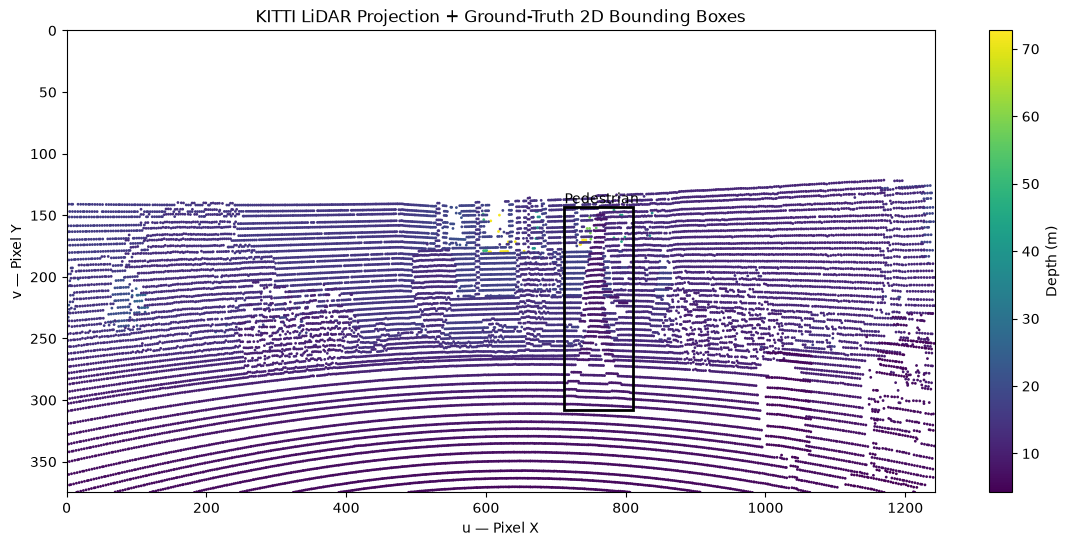

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Project LiDAR points to image plane
u, v, depth = projection(
    rectified_xyz,
    p2
)

# Read KITTI labels
objects = read_labels(
    PATH="../data/KITTI/training/label_2/000000.txt"
)

fig, ax = plt.subplots(figsize=(14, 6))

# LiDAR projected points
scatter = ax.scatter(
    u,
    v,
    c=depth,
    s=1,
    cmap="viridis"
)

# Plot every KITTI bounding box
for obj in objects:

    x1, y1, x2, y2 = obj["bbox"]

    width = x2 - x1
    height = y2 - y1

    rectangle = Rectangle(
        (x1, y1),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    # Object type
    ax.text(
        x1,
        y1,
        obj["type"],
        fontsize=10,
        verticalalignment="bottom"
    )

ax.set_xlabel("u — Pixel X")
ax.set_ylabel("v — Pixel Y")
ax.set_title(
    "KITTI LiDAR Projection + Ground-Truth 2D Bounding Boxes"
)

# Image coordinate convention:
# origin is top-left, v increases downward
ax.set_xlim(0, 1242)
ax.set_ylim(375, 0)

plt.colorbar(
    scatter,
    ax=ax,
    label="Depth (m)"
)

plt.show()